<a href="https://colab.research.google.com/github/proteinovayas13/My_works/blob/main/%D0%94%D0%B8%D0%B0%D0%B1%D0%B5%D1%82_%22SHAP_%D0%B8_LIME_%D1%871_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [An Introduction to SHAP Values and Machine Learning Interpretability](https://www.datacamp.com/tutorial/introduction-to-shap-values-machine-learning-interpretability)

# Прогнозирование с использованием моделей LIME и SHAP.

In [ ]:
!pip install shap

In [ ]:
import shap
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
shap.initjs()

customer = pd.read_csv("diabetes.csv")
customer.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Информация об атрибутах набора данных 💯

Беременности: Для выражения количества беременностей

Глюкоза: Для выражения уровня глюкозы в крови

Артериальное давление: Для выражения измерения артериального давления

Толщина кожи: Для выражения толщины кожи

Инсулин: Для выражения уровня инсулина в крови


In [ ]:
X = customer.drop("Outcome", axis=1) # Independent variables
y = customer.Outcome # Dependent variable

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Train a machine learning model
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Make prediction on the testing data
y_pred = clf.predict(X_test)

# Classification Report
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86       165
           1       0.64      0.82      0.72        66

    accuracy                           0.81       231
   macro avg       0.78      0.82      0.79       231
weighted avg       0.84      0.81      0.82       231



# SHAP

In [ ]:
explainer = shap.Explainer(clf)
shap_values = explainer.shap_values(X_test)

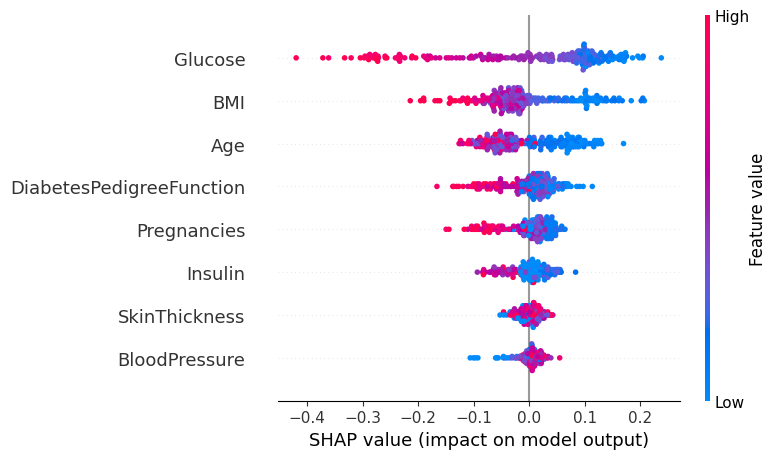

In [ ]:
shap.summary_plot(shap_values[:, :, 0], X_test)

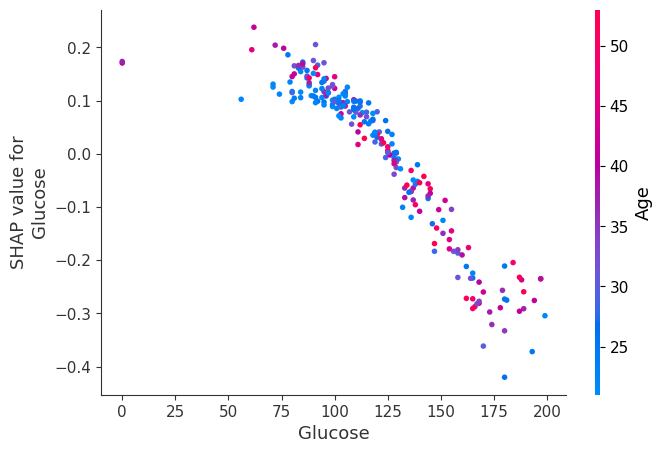

In [ ]:
shap.dependence_plot("Glucose", shap_values[:, :, 0], X_test,interaction_index="Age")

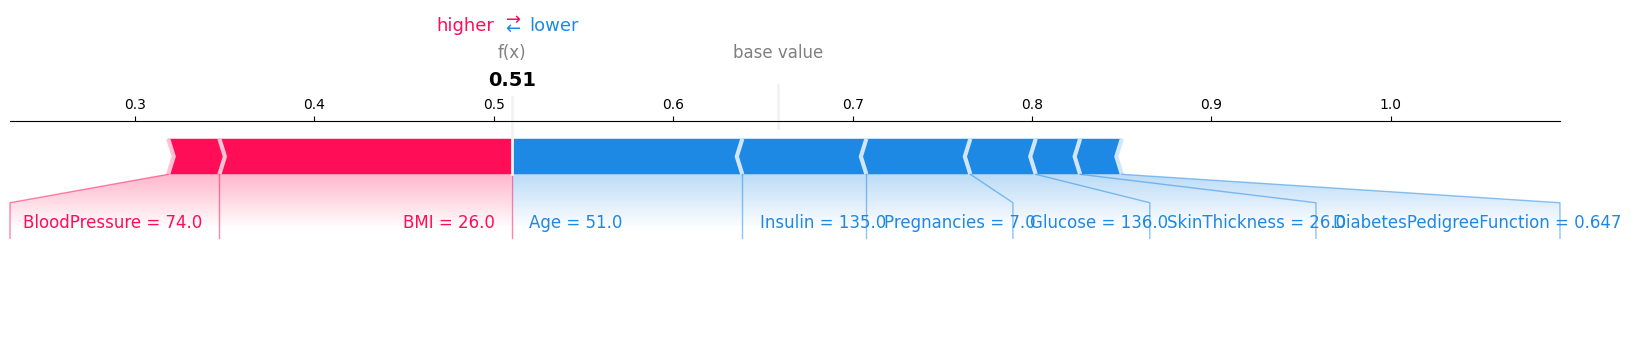

In [ ]:
shap.plots.force(explainer.expected_value[0], shap_values[:, :, 0][0,:], X_test.iloc[0, :], matplotlib = True)

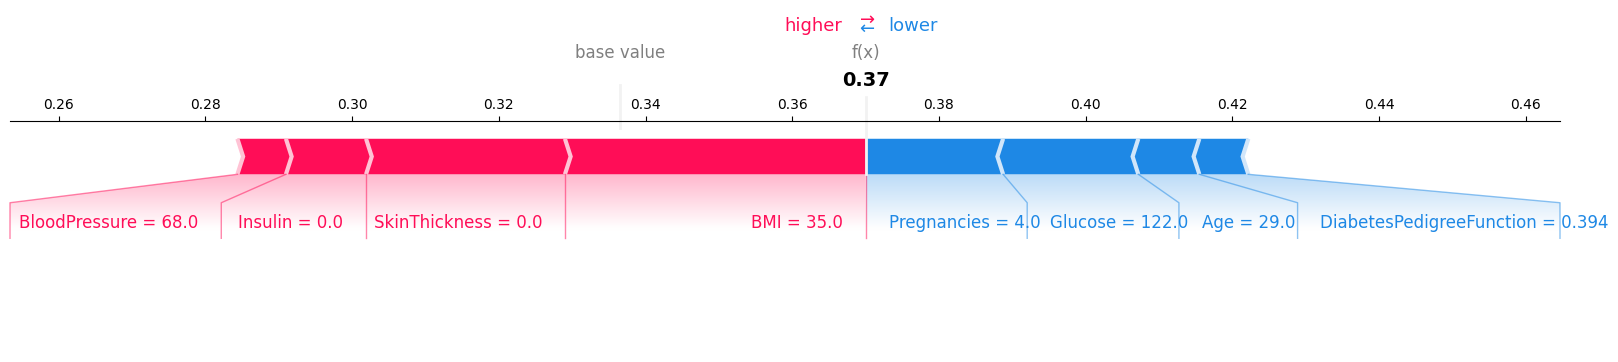

In [ ]:
shap.plots.force(explainer.expected_value[1], shap_values[:, :, 1][6, :], X_test.iloc[6, :],matplotlib = True)

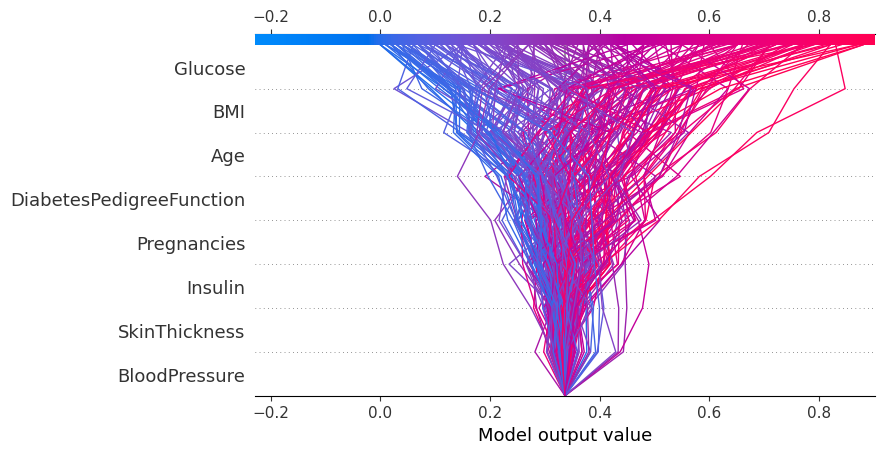

In [ ]:
shap.decision_plot(explainer.expected_value[1], shap_values[:, :, 1], X_test.columns)

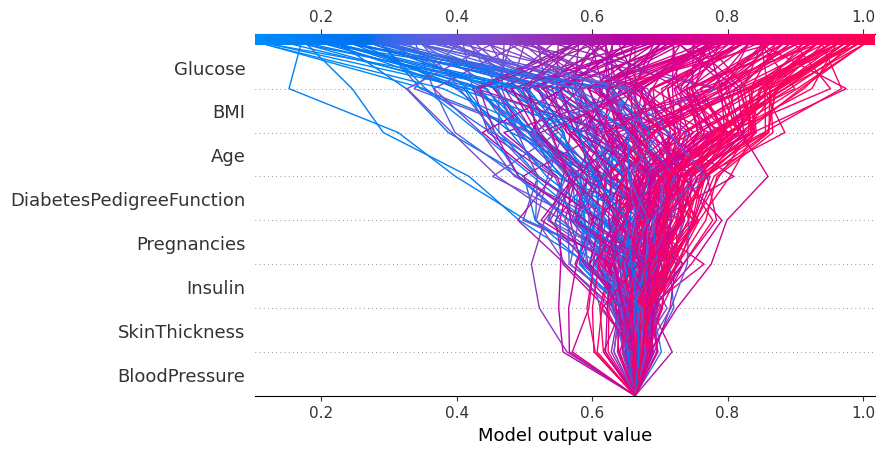

In [ ]:
shap.decision_plot(explainer.expected_value[0], shap_values[:, :, 0], X_test.columns)

# LIME

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=89182cd6e54d85a692ce2ec72a17e2c04599a467dd8fc676414ef437a6edc3f3
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
import lime
from lime import lime_tabular

In [ ]:
# creating an instance of the lime tabular explainer
lime_explainer = lime_tabular.LimeTabularExplainer(training_data=np.array(X_train), feature_names=X_train.columns,
            class_names=['0', '1'], mode='classification')

In [ ]:
# obtaining the explanation
explanation = lime_explainer.explain_instance(data_row=X_test.iloc[1], predict_fn=clf.predict_proba, top_labels=2, num_features=13)

# printing out the explanation
explanation.show_in_notebook()

/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

## Как выявить есть диабет или нет

модель RandomForestClassifier хорошо определяет класс 0,
в совокупности ближе к первому классу

Glucose уровень глюкозы вносит наибольший вклад, на втором месте
bloodPressure (Давление крови), на третьем месте BMI(индекс массы тела)


график зависимост имежду уровнем глюкозы и возраста сильный,
с возрастом уровень гоюкозы растет

после 51 года высокая вероятность диабета